# Opazovanje vodostaja rezervoarja z Analysis-Ready PlanetScope (ARPS) v Planet Insights

Analysis-Ready PlanetScope (ARPS) so na voljo znotraj platforme Planet Insights. ARPS je nova ponudba podjetja Planet, ki pospeši vaše analitične delovne tokove s predobdelanimi in usklajenimi satelitskimi posnetki. V tej nalogi bomo opazovali bomo spreminjanje vodostaja v rezervoarju skozi leto. 

Opravili bomo naslednje korake:

1. Vizualizacija slik z uporabo Processing API
2. Ustvarjanje časovne vrste z uporabo Statistical API
3. Klasifikacija vode s pragovi

Notebook uporablja knjižnico `sentinelhub`, ki omogoča enostavno interakcijo z API-jem Planet. Prepričajte se, da imate nameščeno knjižnico in ustrezne ključe API-ja za dostop do podatkov.

```powershell
conda install sentinelhub
```

## Obseg Cerkniškega jezera

Cerkniško jezero je največje kraško jezero v Sloveniji, ki se nahaja v Notranjski regiji. Je edinstven naravni pojav, saj se njegova velikost in oblika spreminjata glede na letni čas in vremenske razmere. Jezero je znano po svoji bogati biotski raznovrstnosti, saj je dom številnim vrstam ptic, rib in drugih živali. Poleg tega je Cerkniško jezero priljubljena destinacija za turiste, ki želijo uživati v naravi, opazovati ptice ali se sprehajati po okoliških poteh.

In [9]:
%matplotlib inline

import calendar
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import getpass 
import geopandas as gpd

from sentinelhub import (
    CRS,
    DataCollection,
    MimeType,
    SentinelHubRequest,
    SentinelHubStatistical,
    SHConfig,
    parse_time,
    BBox,
    bbox_to_dimensions,
)

## Poverilnice

Sentinel Hub Python SDK zahteva `client_id` in `client_secret`. Da pridobite `client_id` in `client_secret`, morate odpreti [Planet Account](https://www.planet.com/account/) in se prijaviti. Nato pojdite v **Nastavitvah uporabnika** ustvariti novega OAuth odjemalca. Podrobnejša navodila najdete v [Authentication | Planet Documentation](https://docs.planet.com/develop/authentication/).

Ko imate `client_id` in `client_secret`, priporočamo, da v paketu Sentinel Hub Python konfigurirate nov profil. Navodila za konfiguracijo paketa Sentinel Hub Python najdete [Configuration — Sentinel Hub 3.11.5 documentation](https://sentinelhub-py.readthedocs.io/en/latest/configure.html). To je koristno, saj so spremembe v Notebooku običajno le začasne, s shranjevanjem konfiguracije v profil pa vam ni treba vsakič, ko zaženete nov Jupyter Notebook, ustvarjati novih poverilnic ali prepisovati privzetega profila.

Naslednja celica preveri, ali obstaja privzeta konfiguracija. Če je ne najde, vas bo pozvala k vnosu poverilnic, ki jih lahko nato po želji shranite.

In [10]:
from sentinelhub import SHConfig

# Avtentikacija z the Sentinel Hub Python SDK; See docs: https://sentinelhub-py.readthedocs.io/en/latest/configure.html and https://docs.planet.com/develop/authentication
# If no default configuration detected, enter a client ID and secret to authenticate. These can be obtained by creating an OAuth client here: https://insights.planet.com/account
config = SHConfig()
if not config.sh_client_id or not config.sh_client_secret:
    from getpass import getpass
    print('No credentials found, please provide the OAuth client ID and secret.')
    config.sh_client_id = getpass('Client ID: ')
    config.sh_client_secret = getpass('Client Secret: ')
    # Uncomment the following lines to save your credentials to a configuration
    config.save() 
    print(f'Credentials saved to {SHConfig.get_config_location()}')
else:
    print(f'Using credentials stored here: {SHConfig.get_config_location()}')

Using credentials stored here: C:\Users\krost/.config\sentinelhub\config.toml


In [11]:
# Cerknica 2023-2024 
collection_id = "cd4d7b63-d9ae-42be-92ac-4c0bd9acf7f9"

In [12]:
gdf = gpd.read_file(r"podatki\cerknisko_jezero_aoi.geojson")

# Pridobi geometrijo kot objekt Shapely
lake_aoi = gdf.geometry[0].bounds

print(f"Bounds: {lake_aoi}")

Bounds: (14.344726999246575, 45.7158654563292, 14.42815683371174, 45.77666797575711)


In [20]:
# Manjši del jezera, zaradi hitrosti obdelave
lake_aoi = (14.376013187171012, 45.73866640111466, 14.396870645787303, 45.75386703097164)

In [22]:
# Ločljivost ARPS
resolution = 3

# Okvir za jezero
lake_bbox = BBox(bbox=lake_aoi, crs=CRS.WGS84)
lake_size = bbox_to_dimensions(lake_bbox, resolution=resolution)

print(f"Velikost slike pri ločljivosti {resolution} m: {lake_size} pikslov")

Velikost slike pri ločljivosti 3 m: (545, 559) pikslov


## Vizualizacija z API

### Vizualizacija RGB

Za vizualizacijo posnetkov iz Sentinel Hub moramo uporabiti evalscripts, tj. JavaScriptove ukaze za API Processing, ki so podrobneje opisani v [Evalscript](https://docs.sentinel-hub.com/api/latest/evalscript/). Spodnjia skripta vzame rdeči, zeleni in modri pas podatkov APRS ter vrednosti deli z 1000, saj API vrne vrednosti med 0 in 255, podatki ARPS so namreč produkt odbojnosti SR, ki sega približno od 0 do 10.000.

In [23]:
vis_eval = """
//VERSION=3
//True Color

function setup() {
  return {
    input: ["blue", "green", "red", "dataMask"],
    output: { bands: 4 }
  };
}

function evaluatePixel(sample) {
  return [sample.red/1000, sample.green/1000, sample.blue/1000, sample.dataMask];
}
"""

Podatki ARPS so sestavljeni iz več posnetkov, posnetih istega dne, kar pomeni, da nimajo časovnega atributa, temveč le datum. Posnetki so označeni z `00:00:00`; da bi se izognili neželenim izhodnim podatkom, določite čas zajema kot opoldne, tako da zajamete časovni interval okoli polnoči, na katerega je nastavljen sistem ARPS. 

Metapodatki ARPS vključujejo identifikatorje prizorov, ki so časovni žigi, vendar SH trenutno ne omogoča dostopa do metapodatkov. Če pa gostite svoje lastne podatke ARPS, so te informacije na voljo.

In [126]:
date_start = "2023-01-01T12:00:00Z"
date_end = "2024-12-31T12:00:00Z"

# convert to datetime objects for easier manipulation
date_start_dt = parse_time(date_start)
date_end_dt = parse_time(date_end)

In [ ]:
date_sample_start = "2023-03-01T12:00:00Z"
date_sample_end = "2023-03-30T12:00:00Z"

print(f"Zahteva za podatke od {date_sample_start} to {date_sample_end}")

In [113]:
# Sedaj izvedemo klic API-ja za obdelavo, da pridobimo povprečno vrednost vsakega piksla za območje interesa (AOI) in izbrano časovno obdobje.
def request_data(eval, start, end):
    data_collection = DataCollection.define_byoc(collection_id)

    return SentinelHubRequest(  # Create a request for the mean value
        evalscript=eval,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=data_collection,
                time_interval=(start, end)
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=lake_bbox,
        size=lake_size,
        config=config,

        data_folder="../data",
    )

vis =  request_data(vis_eval, date_sample_start, date_sample_end) 


In [114]:
visual = vis.get_data()[0]

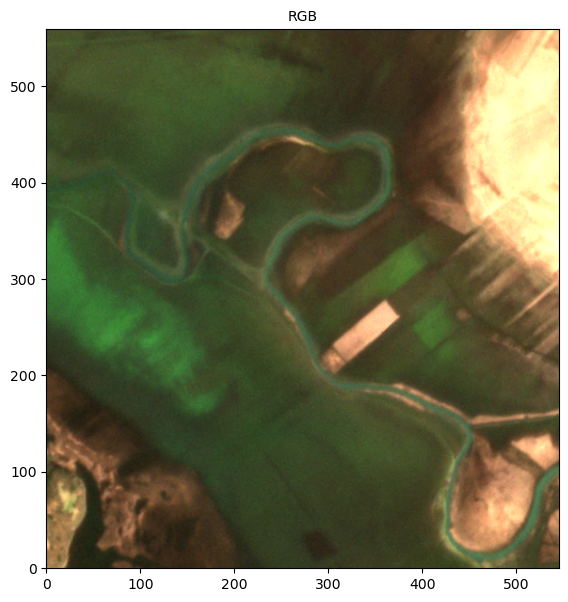

In [115]:
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(7, 7))

ax = axs
aspect_ratio = lake_size[1] / lake_size[0]  # Calculate the aspect ratio
ax.imshow(visual, aspect=aspect_ratio, extent=[0, lake_size[0], 0, lake_size[1]])
ax.set_title(f"RGB", fontsize=10)

plt.show()

### Vizualizacija NDWI

Z uporabo API-ja Processing nismo omejeni zgolj na slike v formatu RGB; skripti evalscript lahko vrnejo katero koli večpasovno sliko, ki ima enak podatkovni tip. V tem primeru bomo izračunali indeks normalizirane razlike v vsebnosti vode (NDWI) in vrnili 32-bitni pas s plavajočo vejico. NDWI se pogosto uporablja za spremljanje sprememb vodnih teles, saj je občutljiv na prisotnost vode. Vrednosti NDWI se gibljejo med -1 in 1, pri čemer višje vrednosti kažejo večjo verjetnost prisotnosti vode.

In [116]:
ndwi_eval = """
//VERSION=3
//NDWI

function setup() {
  return {
    input: ["green", "nir", "dataMask"],
    output: { bands: 1, sampleType: "FLOAT32" }
  };
}

function evaluatePixel(sample) {
  var ndwi = (sample.green - sample.nir ) / (sample.green  + sample.nir );
  return [ndwi];
}
"""

In [117]:
ndwi = request_data(ndwi_eval, date_sample_start, date_sample_end).get_data()[0]

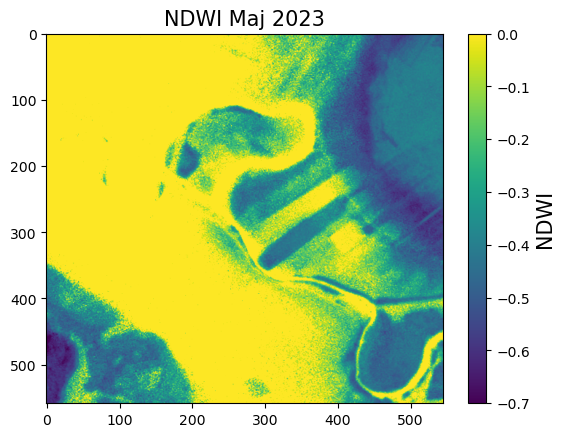

In [118]:
fig, (ax1) = plt.subplots(1, 1)

# Nariši prvo rastrsko sliko
cax1 = ax1.imshow(ndwi, cmap="viridis", aspect="auto", vmin=-0.7, vmax=0)
ax1.set_title("NDWI Maj 2023", fontsize=15)

# Dodaj barvno lestvico za prvo rastrsko sliko
cbar1 = fig.colorbar(cax1, ax=ax1, orientation="vertical")
cbar1.set_label("NDWI", fontsize=15)

## Ustvarjanje časovne vrste using the Statistical API

Z uporabo statističnega API-ja lahko izračunamo povprečno vrednost NDWI za celotno območje zanimanja (AOI) za vsak dan, za katerega imamo podatke.  
Pri UDM2 uporabimo pas `clear` (1 = jasen piksel, 0 = nejasen), skupaj z `dataMask`.

UDM2 pasovi vključujejo:

* `clear`,
* `snow`,
* `shadow`,
* `haze_light`, 
* `haze_heavy`, 
* `cloud`, 
* `confidence`.

In [83]:
ndwi_time_eval = """
//VERSION=3

function setup() {
    return {
        input: [{
            bands: ["green", "nir", "clear", "dataMask"]
        }],
        output: [
            {
                id: "default",
                bands: 1,
                sampleType: "FLOAT32"
            },
            {
                id: "dataMask",
                bands: 1
            }
        ]
    };
}

function evaluatePixel(sample) {
    const clearMask = sample.dataMask * sample.clear; // UDM2: clear=1 means clear pixel
    const denom = sample.green + sample.nir;
    const ndwi = denom !== 0 ? (sample.green - sample.nir) / denom : 0;

    return {
        default: [ndwi],
        dataMask: [clearMask]
    };
}
"""

In [84]:
def get_stats(collection_id, eval):
    # Pulling in data from a colleciton
    data_collection = DataCollection.define_byoc(collection_id)

    # Stat API calc that calculates NDWI within a date range and the AOI for all available imagery
    request = SentinelHubStatistical(
        aggregation=SentinelHubStatistical.aggregation(
            evalscript=eval,
            time_interval=("2023-01-01T12:00:00Z", "2024-12-31T12:00:00Z"),
            aggregation_interval="P1D",
            size=lake_size,
        ),
        input_data=[SentinelHubStatistical.input_data(data_collection, maxcc=1)],
        bbox=lake_bbox,
        config=config,
    )
    return request.get_data()[0]

In [85]:
result =  get_stats(collection_id, ndwi_time_eval)

The response of the stats request has the min, max, mean and standard deviation value of each day, for each band, in this case only 1. But it is not in a useful format for analyzing so we must exctract the data we are interested in.

In [57]:
#Feel free to print all of result, it is just quite long
result['data'][0]

{'interval': {'from': '2023-01-13T12:00:00Z', 'to': '2023-01-14T12:00:00Z'},
 'outputs': {'default': {'bands': {'B0': {'stats': {'min': -0.8063508868217468,
      'max': 0.9931034445762634,
      'mean': -0.01803571093646281,
      'stDev': 0.23668297585475262,
      'sampleCount': 304655,
      'noDataCount': 0}}}}}}

In [58]:
def stats_to_df(stats):
    """Converts the statistics returned by the SentinelHubStatistical request to a pandas DataFrame.
    It also cleans the data and changes the column names to be more user-friendly."""
    stats_copy = stats.copy()
    stats_df = pd.json_normalize(stats_copy["data"])

    # Add more of these if there are more bands
    stats_df.columns = stats_df.columns.str.replace("outputs.default.bands.B0.stats.", "ndwi_")

    # Rename columns
    # We select interval.to due to ARPS data being tagged as captured on 00:00:00
    stats_df = stats_df.rename(columns={"interval.to": "date"})
    stats_df = stats_df.drop(columns=['interval.from'])

    stats_df["date"] = stats_df["date"].apply(parse_time).dt.date
    stats_df = stats_df.set_index("date")


    stats_df = stats_df.apply(pd.to_numeric, errors='coerce')
    

    return stats_df

In [59]:
results = stats_to_df(result)

In [60]:
results

,ndwi_min,ndwi_max,ndwi_mean,ndwi_stDev,ndwi_sampleCount,ndwi_noDataCount
date,,,,,,
2023-01-14,-0.806351,0.993103,-0.018036,0.236683,304655,0
2023-03-16,-0.819662,0.996534,0.029909,0.332003,304655,6966
2023-03-17,-0.761468,0.897638,-0.039381,0.266978,304655,827
2023-03-18,-0.728216,0.993399,0.032767,0.302400,304655,12150
2023-03-21,-0.673327,0.570470,-0.035473,0.268825,304655,11641
...,...,...,...,...,...,...
2024-11-10,-0.790306,0.729537,-0.509939,0.117628,304655,5231
2024-11-15,-0.773940,0.032746,-0.536782,0.064488,304655,0
2024-11-29,-0.906890,0.865169,-0.273080,0.262115,304655,0


Now we have a dataset but you will notice that there are some dates that have NaN values throughout. ARPS is a tiled 24 km X 24 km product. On each given day it will process and mosaic all PS imagery and generate a full tile. Some days only part of the tile will be covered by imagery and the AOI is not, which results in NaN values. Other times an image may have been captured but the entirety of the AOI was covered in clouds so it was masked out, during the filtering that occurs in the evalscript. 

Lastly there are days where a portion of the image will have data but not all of it. Because there is some data present, values will be calculated for NDWI but they will only be representative of the part of the image that has data. Since the portion of the image that has data is random we also want to remove these dates when trying to get a ratio of water to land within an image.

Lets graph the `noDataCount` column in order to get a sense of the distribution.

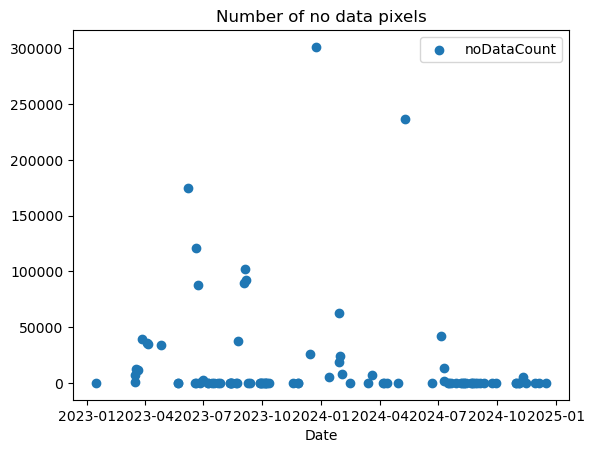

In [61]:
# Plotting the data
plt.scatter(results.index, results['ndwi_noDataCount'], label='noDataCount')


# Adding labels and title
plt.xlabel('Date')
plt.title('Number of no data pixels')
plt.legend()

# Displaying the plot
plt.show()

Lets remove any day that is not entirely covered. Earlier we saw that there were 558,000 pixels total in this AOI

In [62]:
results = results[results['ndwi_noDataCount'] <= 0]
results


,ndwi_min,ndwi_max,ndwi_mean,ndwi_stDev,ndwi_sampleCount,ndwi_noDataCount
date,,,,,,
2023-01-14,-0.806351,0.993103,-0.018036,0.236683,304655,0
2023-05-22,-0.800294,0.818182,-0.103263,0.179572,304655,0
2023-05-23,-0.801913,0.956989,-0.113585,0.177616,304655,0
2023-06-18,-0.834711,-0.035971,-0.561025,0.173136,304655,0
2023-06-20,-0.838509,-0.030192,-0.617527,0.140097,304655,0
...,...,...,...,...,...,...
2024-11-05,-0.817886,0.643836,-0.428251,0.225055,304655,0
2024-11-15,-0.773940,0.032746,-0.536782,0.064488,304655,0
2024-11-29,-0.906890,0.865169,-0.273080,0.262115,304655,0


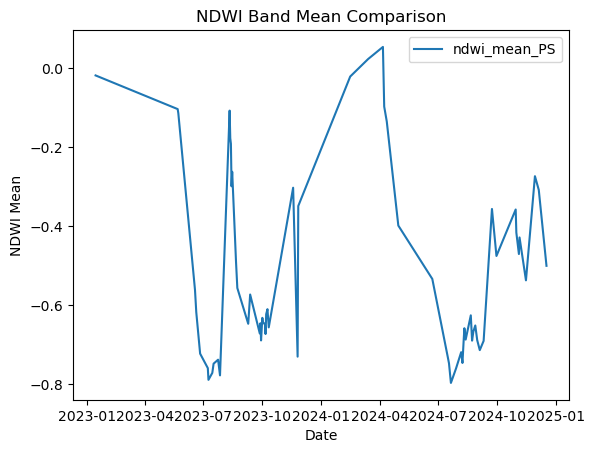

In [63]:
# Plotting the data
plt.plot(results.index, results['ndwi_mean'], label='ndwi_mean_PS')

# Adding labels and title
plt.xlabel('Date')
plt.ylabel('NDWI Mean')
plt.title('NDWI Band Mean Comparison')
plt.legend()

# Displaying the plot
plt.show()

The change in NDWI values throughout the year signifies a change in wetness in our AOI. The lower the mean NDWI value the dryer the region which we would imagine would lead to a smaller lake. To confirm this hypothesis we can rudimentarily classify the imagery throughout the year and measure the lake area. 

## Klasifikacija vode s pragovi

We are going to take our NDWI image from earlier and play around with thresholds for classification. Starting at -.6, the highest mean value and slowly working our way up until only the lake outline remains

Text(0.5, 1.0, 'Water Mask September 29th 2022')

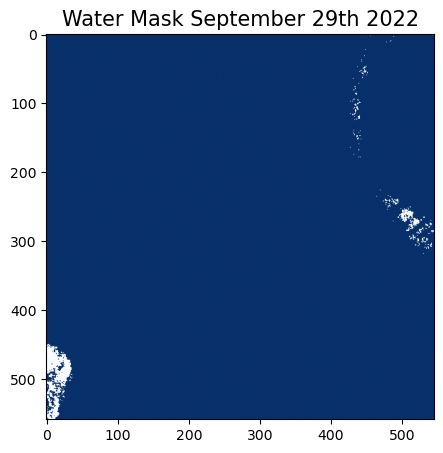

In [119]:
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 5))

# Play around with the threshold value till you get a good binary image of the lake
binary = ndwi > -0.6
cax1 = ax1.imshow(binary, cmap="Blues", aspect="auto")
ax1.set_title("Water Mask September 29th 2022", fontsize=15)

Text(0.5, 1.0, 'Water Mask September 29th 2022')

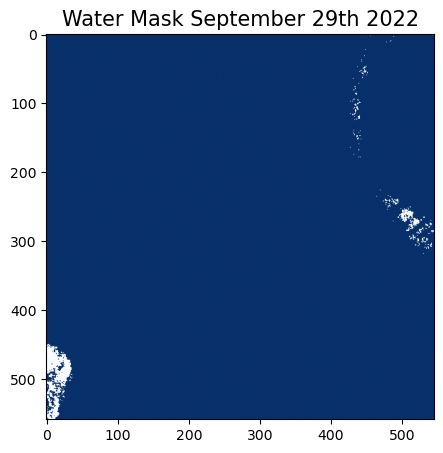

In [120]:

fig, (ax1) = plt.subplots(1, 1, figsize=(5, 5))

# Play around with the threshold value till you get a good binary image of the lake
binary = ndwi > -0.6
cax1 = ax1.imshow(binary, cmap="Blues", aspect="auto")
ax1.set_title("Water Mask September 29th 2022", fontsize=15)


#### Given a threshold we can count the number of pixels above and below that value within our image 

Sentinel Hub has the capability of analyzing multiple images within a time range. This can allow for calculating the mean of RGB or NDWI value per pixel for a given month. Here is the evalscript that will take the sum of each pixel and divide it by the number of pixels present in the time range.

In [122]:
mean_eval = """
//VERSION=3
function setup() {
  return {
    input: ["green", "nir", "dataMask", "clear"],
    output: { bands: 1, sampleType: "FLOAT32" },
    mosaicking: "ORBIT"
  };
}

function evaluatePixel(samples, scenes) {
  var sum_ndwi = 0;
  var count = 0;

  for (var i = 0; i < samples.length; i++) {
    var total_mask = samples[i].dataMask * samples[i].clear; // UDM2 clear=1
    if (total_mask !== 0) {
      var denom = samples[i].green + samples[i].nir;
      if (denom !== 0) {
        sum_ndwi += (samples[i].green - samples[i].nir) / denom;
        count++;
      }
    }
  }

  return [count > 0 ? sum_ndwi / count : 0];
}
"""

Now if we make the call for every month that we have imagery for, starting April 2022. This will take a couple minutes.

In [127]:
year = date_start_dt.year
start_month = date_start_dt.month
monthly_rasters = []

for i in range(5):
    month = (start_month + i - 1) % 12 + 1
    if month == 1 and i != 0:
        year += 1

    # Get the first day of the month
    first_day = datetime(year, month, 1).strftime('%Y-%m-%d')
    # Get the last day of the month
    last_day = datetime(year, month, calendar.monthrange(year, month)[1]).strftime('%Y-%m-%d')
    print(f"Getting data for {first_day} to {last_day}")
    
    # Store the raster data along with the month and year
    raster_data = request_data(mean_eval, first_day, last_day).get_data()[0]
    monthly_rasters.append({
        "year": year,
        "month": month,
        "raster": raster_data
    })

Getting data for 2023-01-01 to 2023-01-31
Getting data for 2023-02-01 to 2023-02-28
Getting data for 2023-03-01 to 2023-03-31
Getting data for 2023-04-01 to 2023-04-30
Getting data for 2023-05-01 to 2023-05-31


Lets look at what the ndwi values for the year look like before we classify our imagery

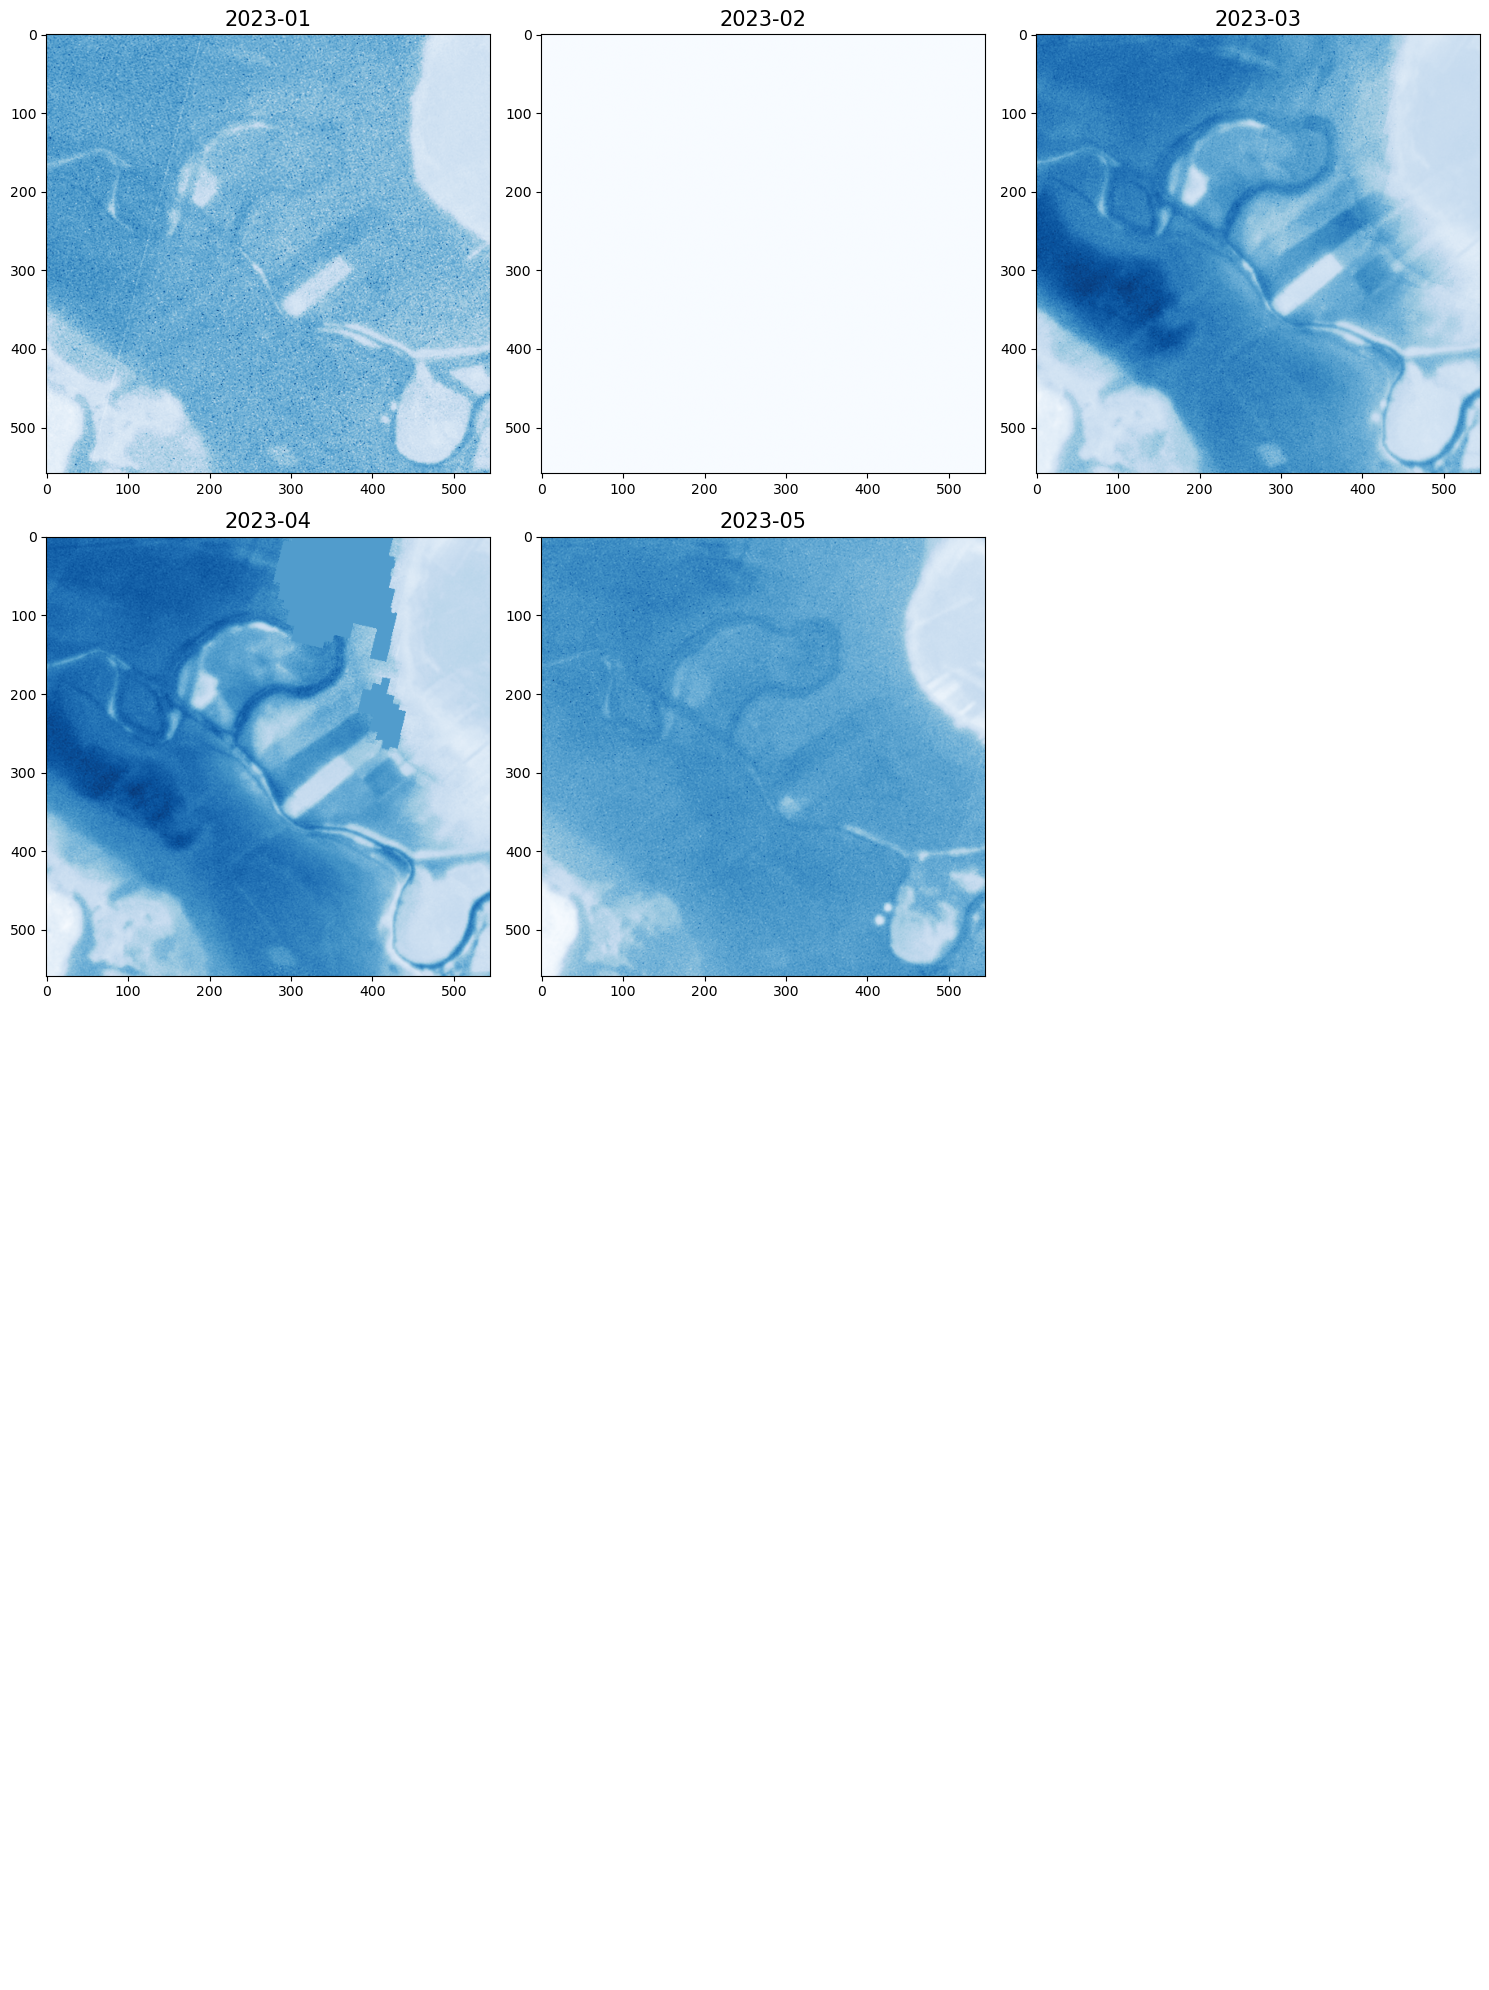

In [128]:
def plot_ndwi_array(monthly_rasters, cmap="Blues"):
    # Create subplots
    fig, axes = plt.subplots(4, 3, figsize=(15, 20))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    for i, entry in enumerate(monthly_rasters):
        # Extract raster and metadata
        ndwi = entry["raster"]
        year = entry["year"]
        month = entry["month"]

        # Plot each NDWI raster
        cax = axes[i].imshow(ndwi, cmap=cmap, aspect="auto")

        # Set title for each subplot using year and month
        axes[i].set_title(f"{year}-{month:02d}", fontsize=15)

    # Hide any unused subplots
    for j in range(len(monthly_rasters), len(axes)):
        axes[j].axis("off")

    # Add colorbar for each subplot
    plt.tight_layout()
    plt.show()

plot_ndwi_array(monthly_rasters)

Now we can plot all of the images using the threshold that we found above

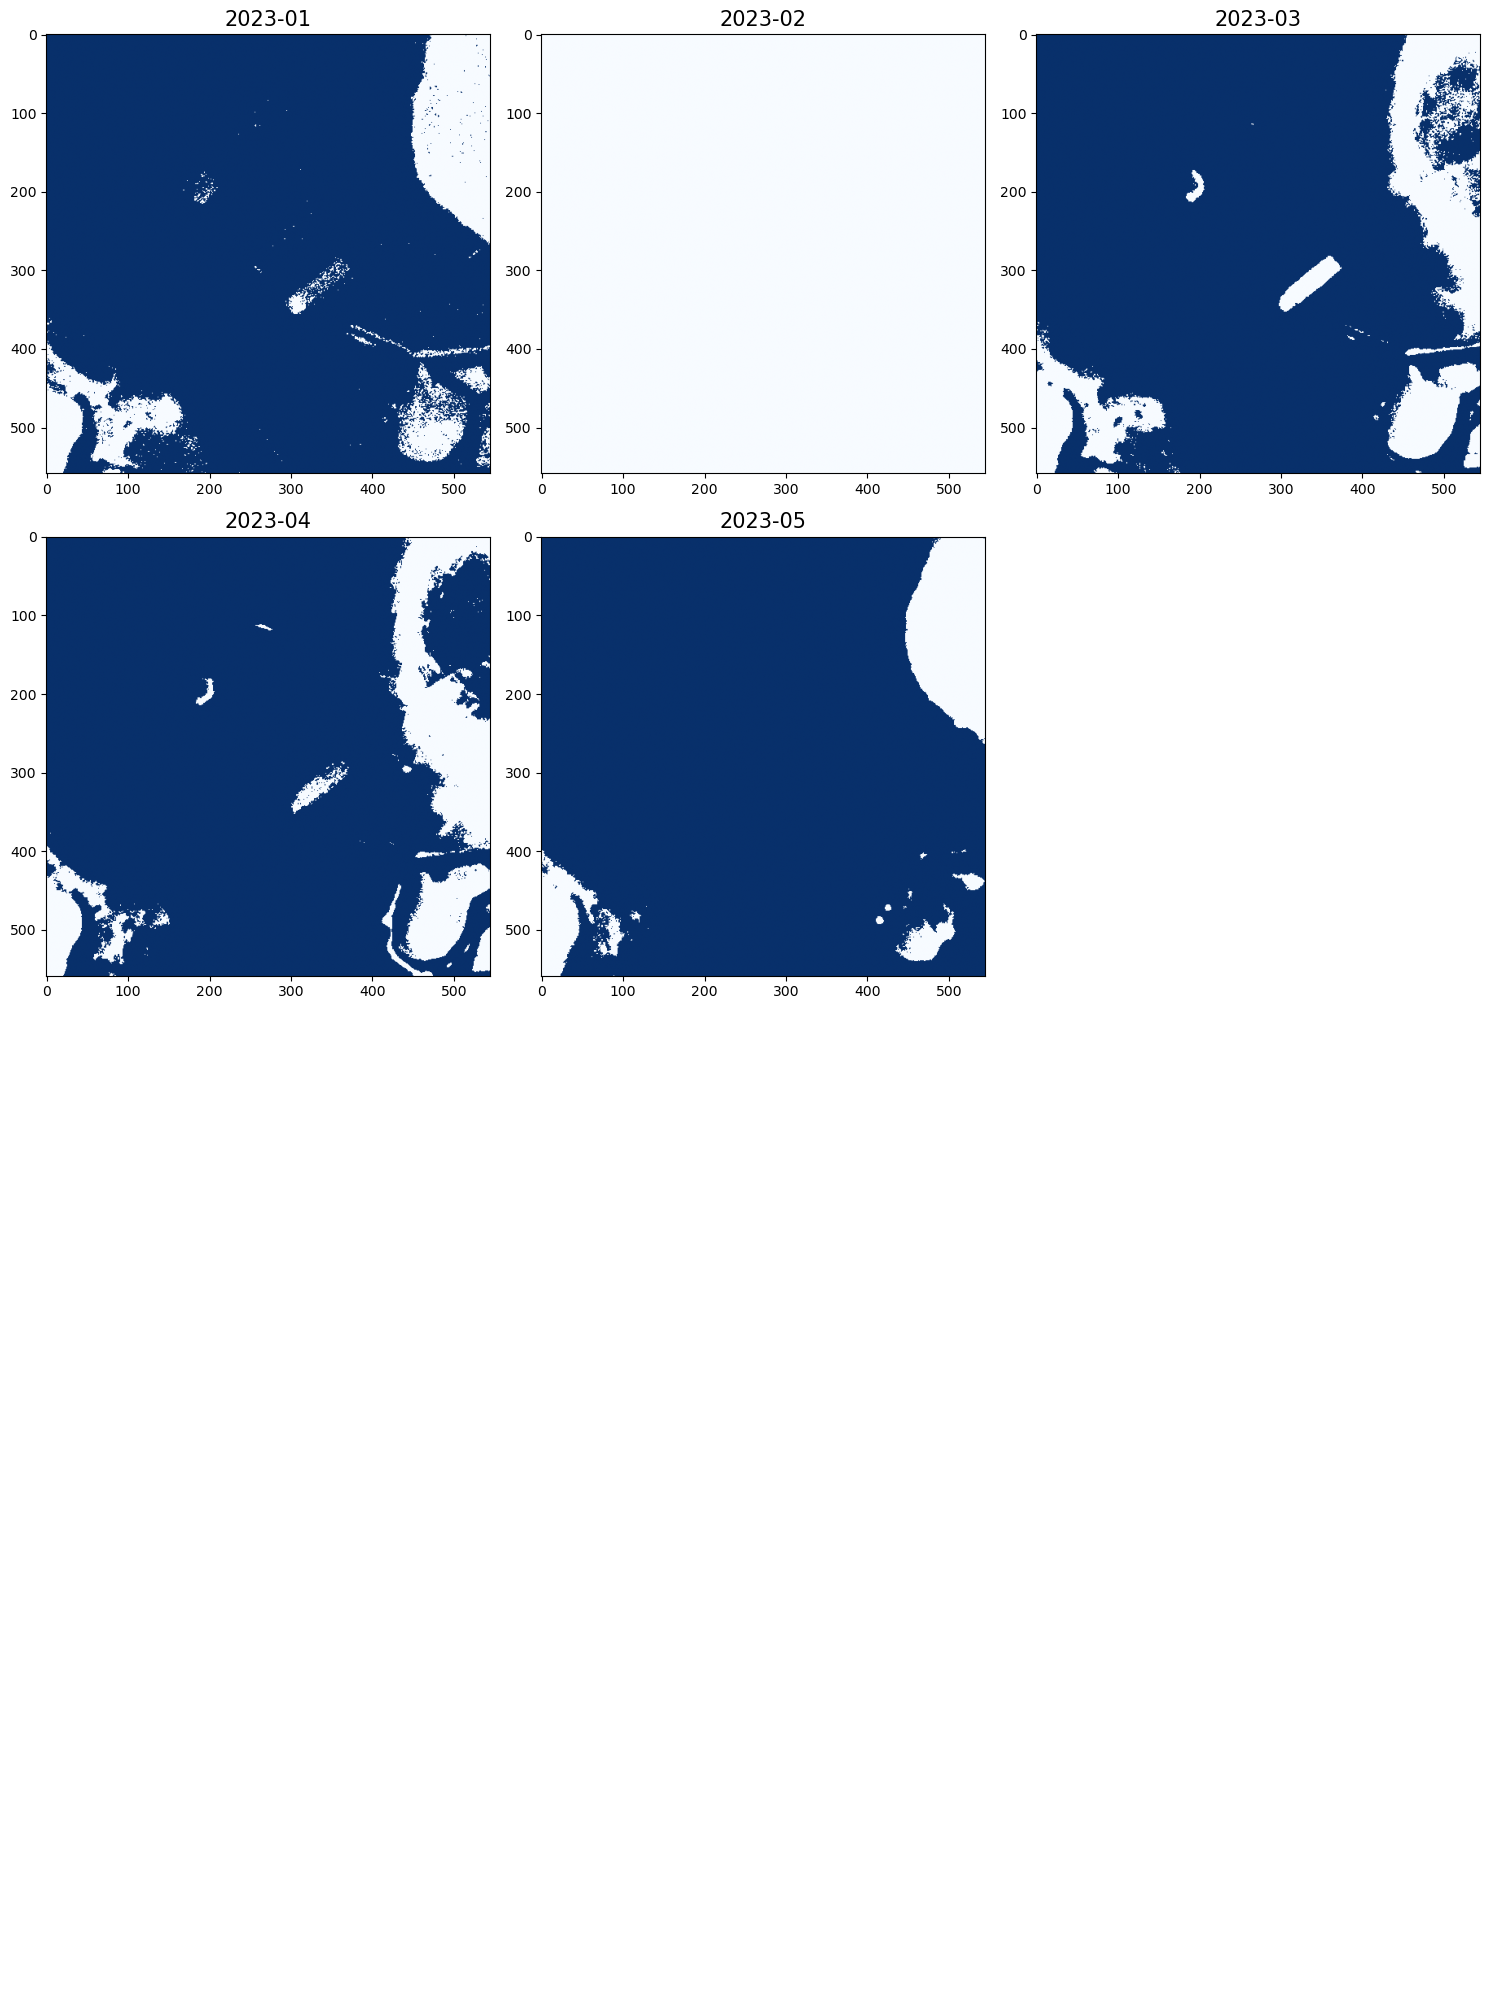

In [129]:
def plot_ndwi_array(monthly_rasters, cmap="Blues"):
    # Create subplots
    fig, axes = plt.subplots(4, 3, figsize=(15, 20))

    # Flatten the axes array for easy iteration
    axes = axes.flatten()

    for i, entry in enumerate(monthly_rasters):
        # Extract raster and metadata
        ndwi = entry["raster"]
        year = entry["year"]
        month = entry["month"]

        # Apply binary threshold to the NDWI raster
        binary = ndwi > -0.40

        # Plot the binary NDWI raster
        cax = axes[i].imshow(binary, cmap=cmap, aspect="auto")

        # Set title for each subplot using year and month
        axes[i].set_title(f"{year}-{month:02d}", fontsize=15)

    # Hide any unused subplots
    for j in range(len(monthly_rasters), len(axes)):
        axes[j].axis("off")

    # Adjust layout
    plt.tight_layout()
    plt.show()

plot_ndwi_array(monthly_rasters)

Finally we can count the area of each month by counting the pixels above the monthly threshold. By plotting it we can see the water fluctuation of the Perth Water resevoir through the year.

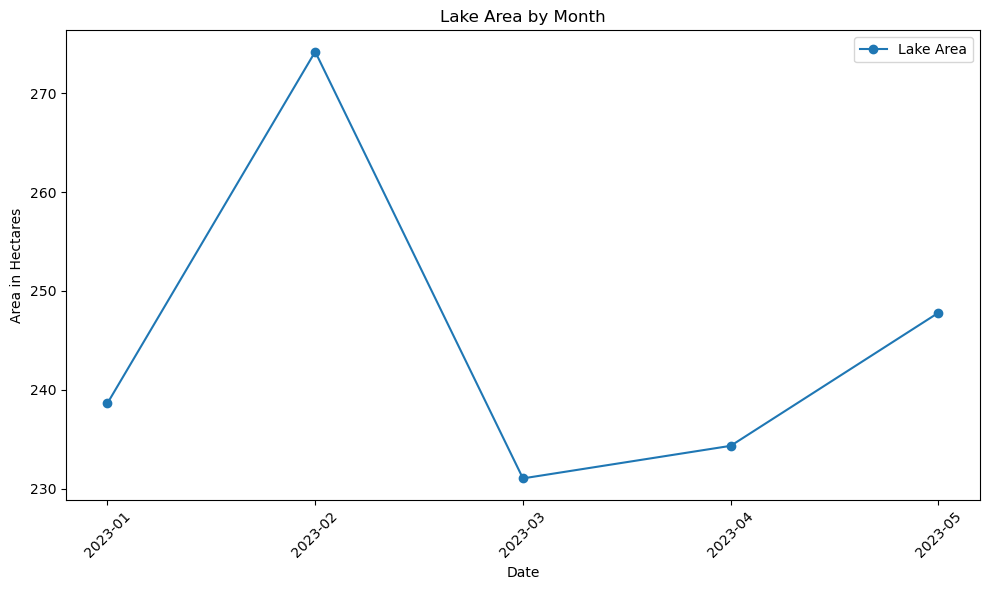

In [130]:
monthly_area = []
dates = []

for entry in monthly_rasters:
    # Extract raster and metadata
    ndwi = entry["raster"]
    year = entry["year"]
    month = entry["month"]

    # Calculate the area where NDWI > -0.40
    area = np.sum(ndwi > -0.40) * 9 / 10000  # Convert to hectares
    monthly_area.append(area)

    # Store the date for the x-axis
    dates.append(f"{year}-{month:02d}")

# Plotting the data
plt.figure(figsize=(10, 6))
plt.plot(dates, monthly_area, label='Lake Area', marker='o')

# Adding labels and title
plt.xlabel('Date')
plt.ylabel('Area in Hectares')
plt.title('Lake Area by Month')
plt.xticks(rotation=45)
plt.legend()

# Displaying the plot
plt.tight_layout()
plt.show()

Our lake area does generally correlate with our earlier wetness/dryness although the largest water extent is measured as far earlier in the season then the wettest point. This basic analysis could be easily repeated year over year to get better annual trends and potentially detect anomalous events in the future!